# L13 : Handwritten Digits (ML introduction)
Here we're going to use the MNIST database. This contains a set of images with handwritten digts. It is one of the most widely used and best studied datasets in the whole of machine learning. 
Let's load the dataset

In [172]:
import numpy as np
from sklearn import datasets
from matplotlib import pyplot as plt
import scipy.stats
import seaborn
from sklearn import datasets
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [174]:
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


Here we plot the images and the corresponding labels

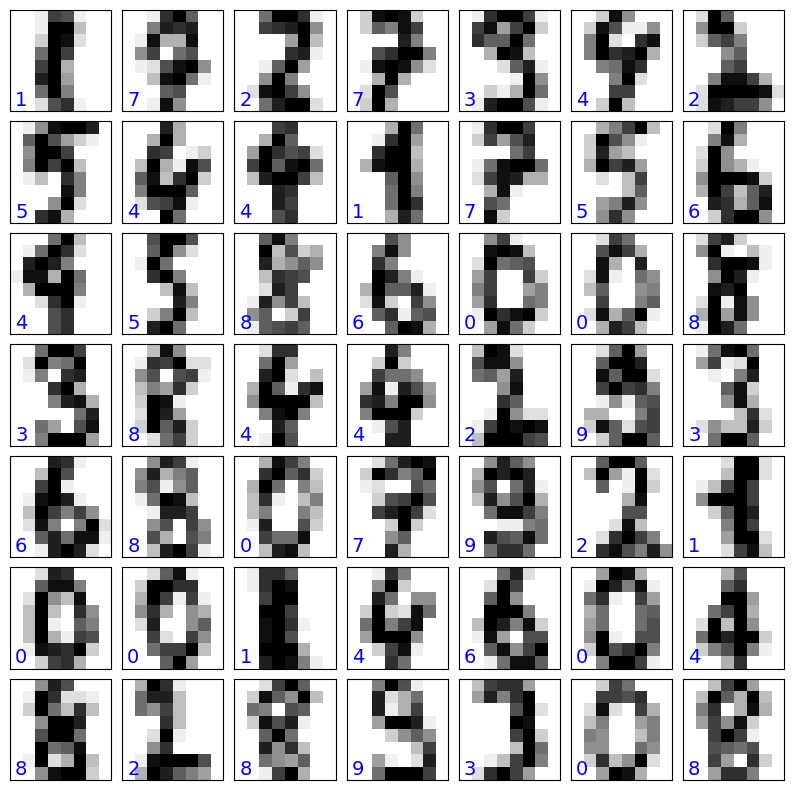

In [177]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='blue', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

Ok so the data is simply each pixel value within an 8x8 grid. For this analysis, we don't care about the 2-D nature of the image, we can just treat it as an 8x8 = 64 dimensional array. So our data have  samples in 1797 dimensions.

In [180]:
print(digits.data.shape)

(1797, 64)


We'd like to visualize our points within the 64-dimensional parameter space, but it's difficult to plot points in 64 dimensions! So we need to reduce the dimensionality of the space.
Use the unsupervised dimensionality reduction technique called Isomap. Isomap is an embedding tecnique, which tries to understand if your N dimensional datapoint live in a M dimensional (with M < N) manyfold. Reduce the MINST dataset. Do some plots to visualize your results

/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/opt/anaconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


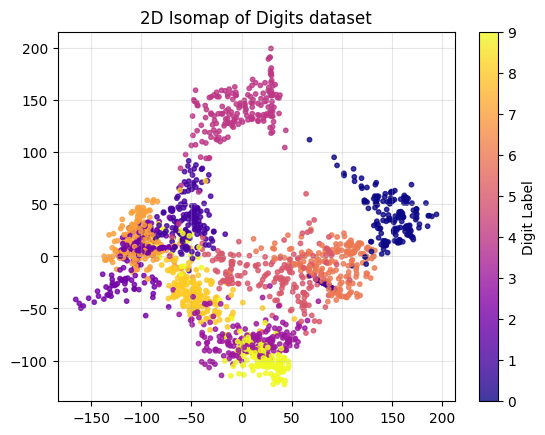

In [183]:
X = digits.data
y = digits.target
isomap = Isomap(n_components=2)
X_iso = isomap.fit_transform(X)

scatter = plt.scatter(X_iso[:, 0], X_iso[:, 1], c=y, cmap='plasma', s=10, alpha=0.8)
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.title("2D Isomap of Digits dataset")
plt.grid(True, alpha=0.3)
plt.show()

Split the dataset taking 80% of the images as tranining dataset and leaving the other 20% as a validation set. You need sklearn.model_selection.train_test_split.
Use a simple Logistic Regression which despite its name is a common classification algorithm. Use the flag solver='sag'

In [208]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(X_train.shape, X_test.shape)

model = LogisticRegression(solver='sag', max_iter=1000, random_state=0)
model.fit(X_train, y_train)

(1437, 64) (360, 64)


LogisticRegression(max_iter=1000, random_state=0, solver='sag')

Compute the accuracy (sklearn.metrics.accuracy_score) of your emulator. In this context, accuracy is simply the fraction of the digits that were correctly identified. Compute the accuracy on both the training and the validation set. Comment on the results.

In [211]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_test, y_test_pred)

print(f"\nAccuracy - Training Set:   {train_acc:.4f}")
print(f"Accuracy - Validation Set: {val_acc:.4f}")


Accuracy - Training Set:   1.0000
Accuracy - Validation Set: 0.9667


The accuracy is a single number doesn't tell us where we've gone wrong. Plot the confusion matrix as we did above. What are the digits that are more challenging to identify, does it make sense?

[[27  0  0  0  0  0  0  0  0  0]
 [ 0 33  0  0  0  0  0  0  1  1]
 [ 0  0 35  1  0  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0  0  0]
 [ 0  0  0  0 29  0  0  1  0  0]
 [ 0  0  0  0  0 38  0  0  0  2]
 [ 0  1  0  0  0  0 43  0  0  0]
 [ 0  0  0  0  1  0  0 38  0  0]
 [ 0  2  1  0  0  0  0  0 36  0]
 [ 0  0  0  0  0  1  0  0  0 40]]


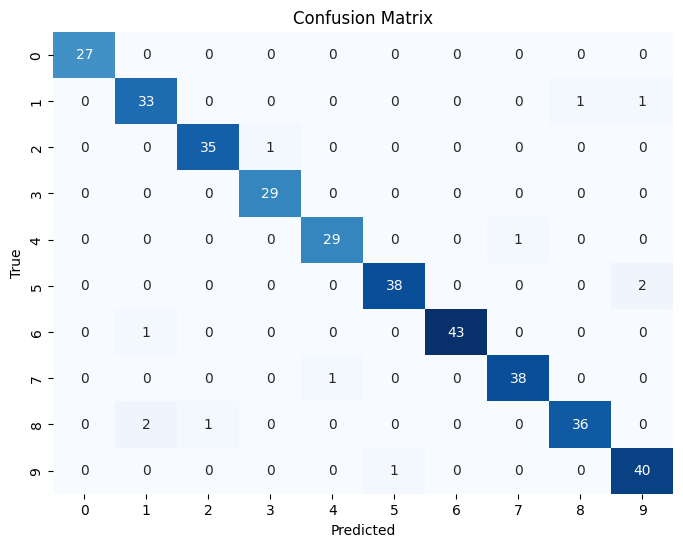

In [214]:
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

plt.figure(figsize=(8, 6))
seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

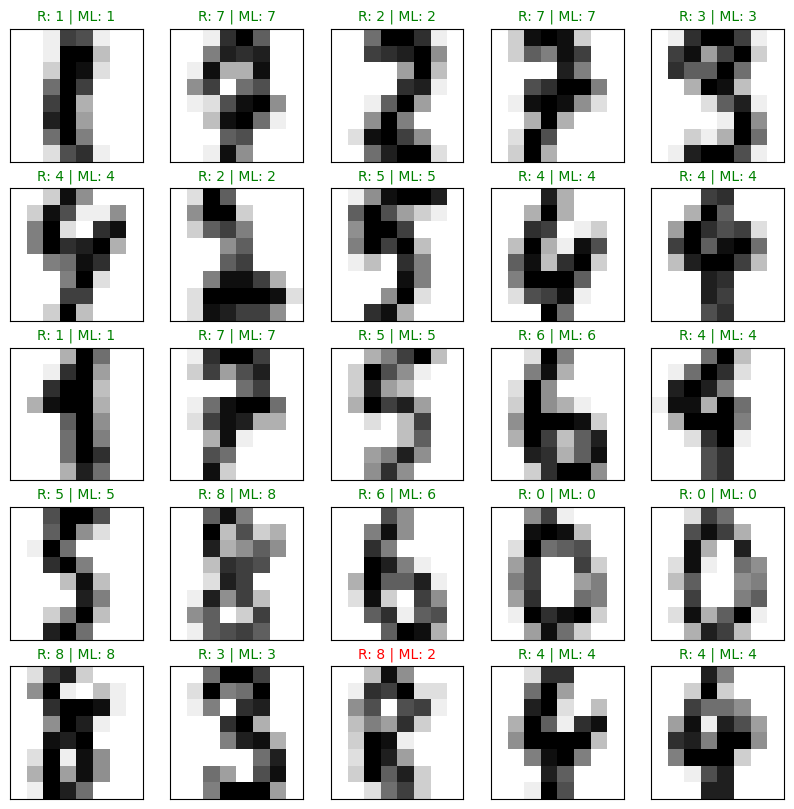

In [216]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    idx = mychoices[i]
    image = digits.images[idx]
    real = digits.target[idx]
    pred = model.predict([digits.data[idx]])[0]

    ax.imshow(image, cmap='binary')
    color = "green" if pred == real else "red"
    ax.set_title(f"R: {real} | ML: {pred}", color=color, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

# Me vs Model

In [219]:
np.random.seed(123) 
selected_indices = np.random.choice(digits.images.shape[0],25)

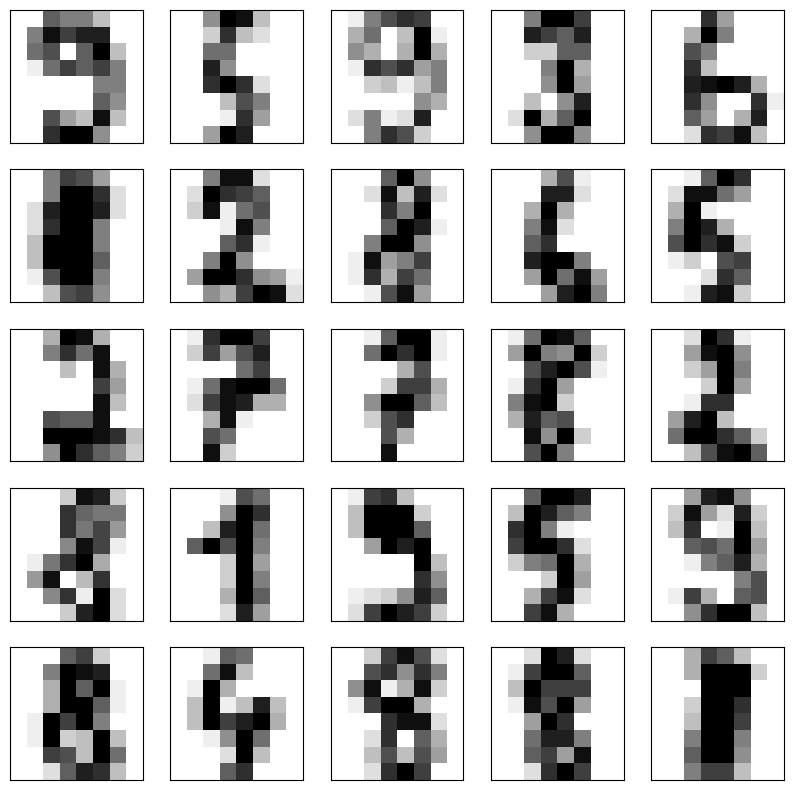

In [221]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[selected_indices[i]], cmap='binary')
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [223]:
my_guesses = [9, 5, 8, 3, 6, 1, 2, 8, 6, 5, 2, 7, 7, 8, 2, 8, 1, 9, 5, 3, 8, 4, 3, 8, 1]

In [225]:
true_labels = digits.target[selected_indices]
model_predictions = model.predict(digits.data[selected_indices])
def compute_accuracy(preds, truths):
    return np.mean(np.array(preds) == np.array(truths))

my_accuracy = compute_accuracy(my_guesses, true_labels)
model_accuracy = compute_accuracy(model_predictions, true_labels)

print(f"My accuracy: {my_accuracy:.4f}")
print(f"Model Accuracy : {model_accuracy:.4f}")

My accuracy: 0.8800
Model Accuracy : 1.0000


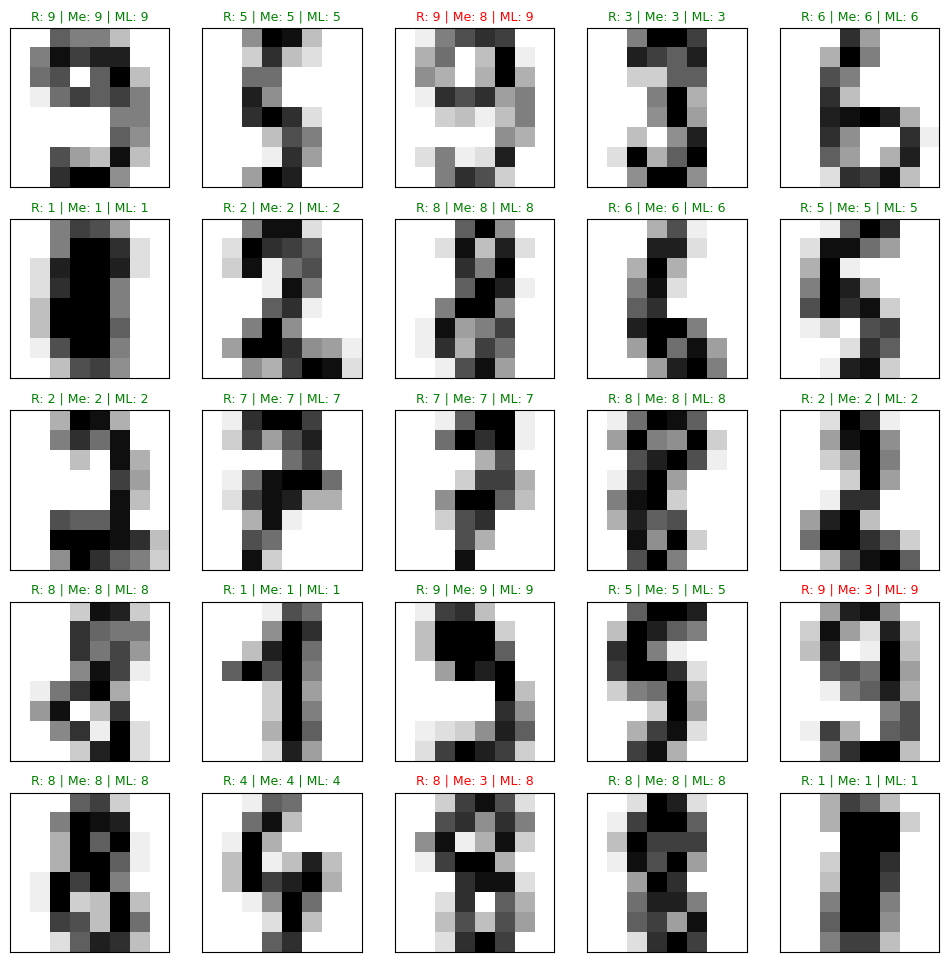

In [227]:
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    idx = selected_indices[i]
    ax.imshow(digits.images[idx], cmap='binary')
    real = true_labels[i]
    your_guess = my_guesses[i]
    model_guess = model_predictions[i]
    color = "green" if your_guess == real else "red"
    ax.set_title(f"R: {real} | Me: {your_guess} | ML: {model_guess}", color=color, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()